In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, average_precision_score

In [14]:
scratch_noResiduals = "predictions_noResiduals_from_scratch_epoch_04.csv"
scratch_wResiduals = "predictions_wResiduals_from_scratch_epoch_04.csv"

imagenet_noResiduals = "predictions_noResiduals_from_imagenet_epoch_5.csv"
imagenet_wResiduals = "predictions_wResiduals_from_imagenet__epoch_4.csv"

ufd = "ufd_predictions.csv"

SUBSETS = ["dalle3", "kandinsky2","kandinsky3","midjourney","pixart1024",
            "playground-25","sdxl","sdxl-dpo","segmoe","ssd1b","stable-cascade",
            "vega","wurstchen2"]

## Createing summary of results


In [15]:
def create_summary(csv_path, categories):
    df = pd.read_csv(csv_path)
    
    df['pred'] = (df['prob'] >= 0.5).astype(int)
    df['correct'] = (df['pred'] == df['label'])
    
    results = []
    valid_aurocs = []
    weights = []

    for cat in categories:
        group_df = df[df['key'].str.contains(cat, case=False, na=False)]
        
        if len(group_df) == 0:
            continue

        real_subset = group_df[group_df['label'] == 0]
        fake_subset = group_df[group_df['label'] == 1]

        acc_real = real_subset['correct'].mean() if not real_subset.empty else np.nan
        acc_fake = fake_subset['correct'].mean() if not fake_subset.empty else np.nan

        precision = precision_score(group_df['label'], group_df['pred'], zero_division=0)
        recall = recall_score(group_df['label'], group_df['pred'], zero_division=0)
        f1 = f1_score(group_df['label'], group_df['pred'], zero_division=0)

        ap = average_precision_score(group_df['label'], group_df['prob'])
    

        try:
            group_auroc = roc_auc_score(group_df['label'], group_df['prob'])
            valid_aurocs.append(group_auroc)
            weights.append(len(group_df))
        except ValueError:
            group_auroc = np.nan

        results.append({
            "Category": cat,
            "Total": len(group_df),
            "Overall Acc": group_df['correct'].mean(),
            "AUROC": group_auroc,
            "Average precision": ap,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Real Acc": acc_real,
            "Fake Acc": acc_fake
        })

    summary = pd.DataFrame(results)

    print("\n" + "="*95)
    print(f"{'PERFORMANCE REPORT':^95}")
    print(f"{csv_path:^95}")
    print("="*95)
    print(summary.to_string(
        index=False, 
        justify='center',
        formatters={
            'Overall Acc': '{:,.2%}'.format,
            'AUROC': lambda x: f"{x:.4f}" if not np.isnan(x) else "N/A",
            'Average precision': '{:,.2%}'.format,
            'Precision': '{:,.2%}'.format,
            'Recall': '{:,.2%}'.format,
            'F1': '{:,.2%}'.format,
            'Real Acc': '{:,.2%}'.format,
            'Fake Acc': '{:,.2%}'.format
        }
    ))

    # Macro averages (mean of per-group metrics)
    macro_avg_auc = np.mean(valid_aurocs) if valid_aurocs else 0
    weighted_avg_auc = np.average(valid_aurocs, weights=weights) if valid_aurocs else 0
    macro_precision = summary['Precision'].mean()
    macro_recall = summary['Recall'].mean()
    macro_f1 = summary['F1'].mean()
    macro_ap = summary["Average precision"].mean()

    print("-" * 95)
    print(f"Macro-Average AUROC (Mean of Groups): {macro_avg_auc:.4f}")
    #print(f"Weighted-Average AUROC (Size Adjusted): {weighted_avg_auc:.4f}")
    #print(f"Macro-Average Precision: {macro_precision:.2%}")
    #print(f"Macro-Average Recall: {macro_recall:.2%}")
    #print(f"Macro-Average F1: {macro_f1:.2%}")
    print(f"Macro-Average AP: {macro_ap:.2%}")
    print("="* 95)
    
    print(len(df))
    return summary

In [20]:
create_summary(imagenet_wResiduals, SUBSETS)


                                      PERFORMANCE REPORT                                       
                       predictions_wResiduals_from_imagenet__epoch_4.csv                       
   Category     Total Overall Acc AUROC  Average precision Precision Recall   F1   Real Acc Fake Acc
        dalle3  4670     66.15%   0.7714       75.85%        79.32%  43.68% 56.34%  88.61%   43.68% 
    kandinsky2  7559     59.65%   0.6770       67.07%        73.35%  30.30% 42.88%  88.99%   30.30% 
    kandinsky3  6400     63.14%   0.6570       61.06%        68.05%  28.89% 40.56%  89.54%   28.89% 
    midjourney  3574     57.47%   0.6617       65.44%        72.70%  23.85% 35.92%  91.05%   23.85% 
    pixart1024  7162     56.88%   0.6264       63.08%        70.77%  23.46% 35.23%  90.31%   23.46% 
 playground-25  6520     51.44%   0.5126       52.74%        57.10%  11.60% 19.28%  91.29%   11.60% 
          sdxl 15512     70.88%   0.8177       81.62%        83.50%  52.05% 64.13%  89.71%   52.05% 

,Category,Total,Overall Acc,AUROC,Average precision,Precision,Recall,F1,Real Acc,Fake Acc
0,dalle3,4670,0.661456,0.771389,0.758460,0.793157,0.436831,0.563380,0.886081,0.436831
1,kandinsky2,7559,0.596507,0.676996,0.670695,0.733504,0.302990,0.428839,0.889947,0.302990
2,kandinsky3,6400,0.631406,0.656972,0.610614,0.680473,0.288945,0.405644,0.895407,0.288945
3,midjourney,3574,0.574706,0.661733,0.654404,0.726962,0.238522,0.359191,0.910515,0.238522
4,pixart1024,7162,0.568836,0.626422,0.630789,0.707666,0.234571,0.352349,0.903100,0.234571
5,playground-25,6520,0.514417,0.512639,0.527383,0.570997,0.115951,0.192759,0.912883,0.115951
6,sdxl,15512,0.708806,0.817691,0.816150,0.834953,0.520500,0.641252,0.897112,0.520500
7,sdxl-dpo,7620,0.755118,0.854962,0.854135,0.854227,0.615223,0.715288,0.895013,0.615223
8,segmoe,7432,0.587191,0.666592,0.666105,0.729462,0.277180,0.401716,0.897201,0.277180
9,ssd1b,7444,0.612574,0.713233,0.710988,0.763854,0.325900,0.456874,0.899248,0.325900


## AUROC

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_auroc_multiple(dfs, labels, save_path=None):

    plt.figure(figsize=(8, 6))

    for df, label in zip(dfs, labels):

        fpr, tpr, _ = roc_curve(df['label'], df['prob'])
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr, tpr,
            linewidth=2,
            label=f"{label} (AUC = {roc_auc:.4f})"
        )

    # Random baseline
    plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC Comparison Across Models")
    plt.legend(loc="lower right")
    plt.grid()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    else:
        plt.show()

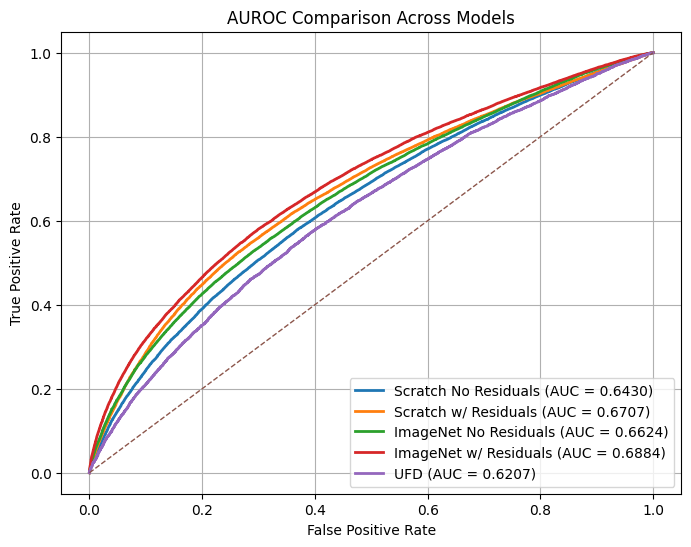

In [46]:
df1 = pd.read_csv(scratch_noResiduals)
df2 = pd.read_csv(scratch_wResiduals)
df3 = pd.read_csv(imagenet_noResiduals)
df4 = pd.read_csv(imagenet_wResiduals)
df5 = pd.read_csv(ufd)

plot_auroc_multiple(
    dfs=[df1, df2, df3, df4, df5],
    labels=[
        "Scratch No Residuals",
        "Scratch w/ Residuals",
        "ImageNet No Residuals",
        "ImageNet w/ Residuals",
        "UFD"
    ],
    save_path="auroc_comparison.png"
)

## Presission Recall Curve


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_multiple(dfs, labels, save_path=None):

    plt.figure(figsize=(8, 6))

    for df, label in zip(dfs, labels):

        precision, recall, _ = precision_recall_curve(df['label'], df['prob'])
        ap = average_precision_score(df['label'], df['prob'])

        plt.plot(
            recall, precision,
            linewidth=2,
            label=f"{label} (AP = {ap:.4f})"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve Comparison")
    plt.legend(loc="lower left")
    plt.grid()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    else:
        plt.show()

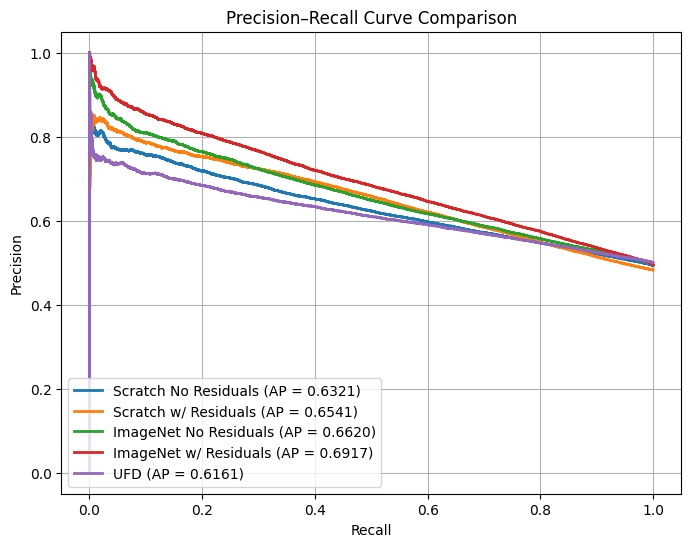

In [23]:
df1 = pd.read_csv(scratch_noResiduals)
df2 = pd.read_csv(scratch_wResiduals)
df3 = pd.read_csv(imagenet_noResiduals)
df4 = pd.read_csv(imagenet_wResiduals)
df5 = pd.read_csv(ufd)

plot_pr_multiple(
    dfs=[df1, df2, df3, df4, df5],
    labels=[
        "Scratch No Residuals",
        "Scratch w/ Residuals",
        "ImageNet No Residuals",
        "ImageNet w/ Residuals",
        "UFD"
    ],
    save_path="pr_comparison.png"
)

## Precision @ 0.8 recall

In [31]:
def precision_at_recall_interp(df, target_recall=0.5):
    
    y_true, y_scores = df['label'], df['prob']
    precisions, recalls, _ = precision_recall_curve(y_true, y_scores)

    if target_recall > max(recalls):
        return 0.0

    precision= np.interp(target_recall, recalls[::-1], precisions[::-1])

    return f"Precision at {target_recall}: {precision}"

In [37]:
precision_at_recall_interp(df4)

'Precision at 0.5: 0.6836683886226427'